# Electromagnetic Induction Prediction using Machine Learning

# Introduction

**Project Overview**
This project bridges classical physics and modern machine learning. We simulate electromagnetic induction using Faraday’s Law, generate a large synthetic dataset, explore it visually, engineer physics-based features, and train multiple regression models to predict the induced electromotive force (EMF). An interactive prediction system, dynamic Plotly animations, and a thorough discussion of the physics-AI connection make this a portfolio-quality work.

**Problem Statement**
Given a coil with known parameters (number of turns, area, orientation) immersed in a magnetic field, can we accurately predict the induced voltage using machine learning trained on simulated physics data?

**Objectives**
Implement Faraday’s Law of Induction in Python.

Generate 10,000+ realistic electromagnetic induction samples.

Perform thorough exploratory data analysis and physics-based visualisation.

Engineer domain-specific features to improve model performance.

Train and compare linear & ensemble regression models.

Build an interactive tool that predicts EMF from user inputs.

Create animated plots showing coil rotation and voltage generation.

**Physics + Machine Learning Connection**
The governing equation is Faraday’s Law:

$$
E = -N \frac{d\Phi}{dt}
$$

where the magnetic flux is:

$$
\Phi = B A \cos(\theta)
$$

Where:

- $E$ = induced electromotive force (EMF)
- $N$ = number of turns in the coil
- $\Phi$ = magnetic flux
- $B$ = magnetic field strength
- $A$ = area of the coil
- $\theta$ = angle between magnetic field and coil
- $\frac{d\Phi}{dt}$ = rate of change of magnetic flux
Because the relationship is deterministic and smooth, a machine learning model can learn it from data. Physics knowledge guides feature selection, data generation, and interpretation—making the model more robust than a pure black-box approach.

**Applications:** electric generators, transformers, wind turbines, electric motors.

## Import Libraries

In [2]:
# Data handling
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Interactive widgets
from ipywidgets import interact, FloatSlider, IntSlider

# Miscellaneous
import warnings
warnings.filterwarnings('ignore')

## Create Physics Simulation

In [3]:
def calculate_magnetic_flux(B, A, theta):
    """
    Compute magnetic flux through a coil.
    Φ = B * A * cos(θ)
    """
    return B * A * np.cos(theta)

def calculate_flux_change(B, A, omega, theta):
    """
    Compute rate of change of flux (dΦ/dt) for a rotating coil.
    Assuming constant B and A, and θ = ω·t.
    dΦ/dt = -B * A * ω * sin(θ)
    """
    return -B * A * omega * np.sin(theta)

def calculate_induced_emf(N, dphi_dt):
    """
    Apply Faraday's Law: EMF = -N * dΦ/dt.
    Returns the induced EMF.
    """
    return -N * dphi_dt

def simulate_coil_motion(B, A, N, omega, time_array):
    """
    Simulate flux and induced EMF over time for a coil rotating
    with constant angular velocity ω.
    """
    theta = omega * time_array  # angular position at each time
    flux = calculate_magnetic_flux(B, A, theta)
    dphi_dt = calculate_flux_change(B, A, omega, theta)
    emf = calculate_induced_emf(N, dphi_dt)
    return time_array, theta, flux, emf

def generate_emf_dataset(n_samples=10000, random_state=42):
    """
    Generate a realistic dataset of electromagnetic induction
    by randomly sampling coil and field parameters.
    """
    np.random.seed(random_state)
    
    # Realistic parameter ranges
    B = np.random.uniform(0.1, 2.0, n_samples)        # Tesla
    A = np.random.uniform(0.001, 0.1, n_samples)      # m²
    N = np.random.randint(10, 1001, n_samples)         # turns
    freq = np.random.uniform(10, 100, n_samples)       # Hz
    omega = 2 * np.pi * freq                           # rad/s
    theta = np.random.uniform(0, 2*np.pi, n_samples)   # rad
    
    # Derived physics quantities
    magnetic_flux = calculate_magnetic_flux(B, A, theta)
    flux_change_rate = calculate_flux_change(B, A, omega, theta)
    induced_emf = calculate_induced_emf(N, flux_change_rate)
    
    # Build DataFrame
    df = pd.DataFrame({
        'magnetic_field': B,
        'coil_area': A,
        'number_of_turns': N,
        'coil_angle': theta,
        'frequency': freq,
        'angular_velocity': omega,
        'magnetic_flux': magnetic_flux,
        'flux_change_rate': flux_change_rate,
        'induced_emf': induced_emf
    })
    
    return df

## Generate Synthetic Physics Data

In [4]:
# Generate 10,000 samples
df = generate_emf_dataset(n_samples=10000)

# Save to CSV for reproducibility
df.to_csv('electromagnetic_induction_data.csv', index=False)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (10000, 9)


,magnetic_field,coil_area,number_of_turns,coil_angle,frequency,angular_velocity,magnetic_flux,flux_change_rate,induced_emf
0,0.811626,0.037990,863,3.187352,20.276539,127.401253,-0.030802,0.179692,-155.074322
1,1.906357,0.033958,267,3.924786,74.708087,469.404756,-0.045877,21.439908,-5724.455549
2,1.490788,0.018439,397,5.369433,84.167885,528.842419,0.016790,11.510691,-4569.744197
3,1.237451,0.061119,54,1.459710,75.592558,474.962049,0.008384,-35.701041,1927.856229
4,0.396435,0.048186,278,2.789864,30.620320,192.393145,-0.017933,-1.266184,351.999029


## Data Exploration

In [5]:
# Basic information
print(df.info())
print(df.describe().round(4))
print(f'Missing values:\n{df.isnull().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   magnetic_field    10000 non-null  float64
 1   coil_area         10000 non-null  float64
 2   number_of_turns   10000 non-null  int32  
 3   coil_angle        10000 non-null  float64
 4   frequency         10000 non-null  float64
 5   angular_velocity  10000 non-null  float64
 6   magnetic_flux     10000 non-null  float64
 7   flux_change_rate  10000 non-null  float64
 8   induced_emf       10000 non-null  float64
dtypes: float64(8), int32(1)
memory usage: 664.2 KB
None
       magnetic_field   coil_area  number_of_turns  coil_angle   frequency  \
count      10000.0000  10000.0000       10000.0000  10000.0000  10000.0000   
mean           1.0389      0.0509         506.7107      3.1275     54.6192   
std            0.5465      0.0286         285.6162      1.8205     25.7654   
min    

#### Dataset characteristics:

10,000 samples, 9 columns (8 features + target)

All features are numeric; no missing values.

Induced EMF ranges approximately from -200 V to +200 V (depending on parameters).



## Exploratory Data Analysis

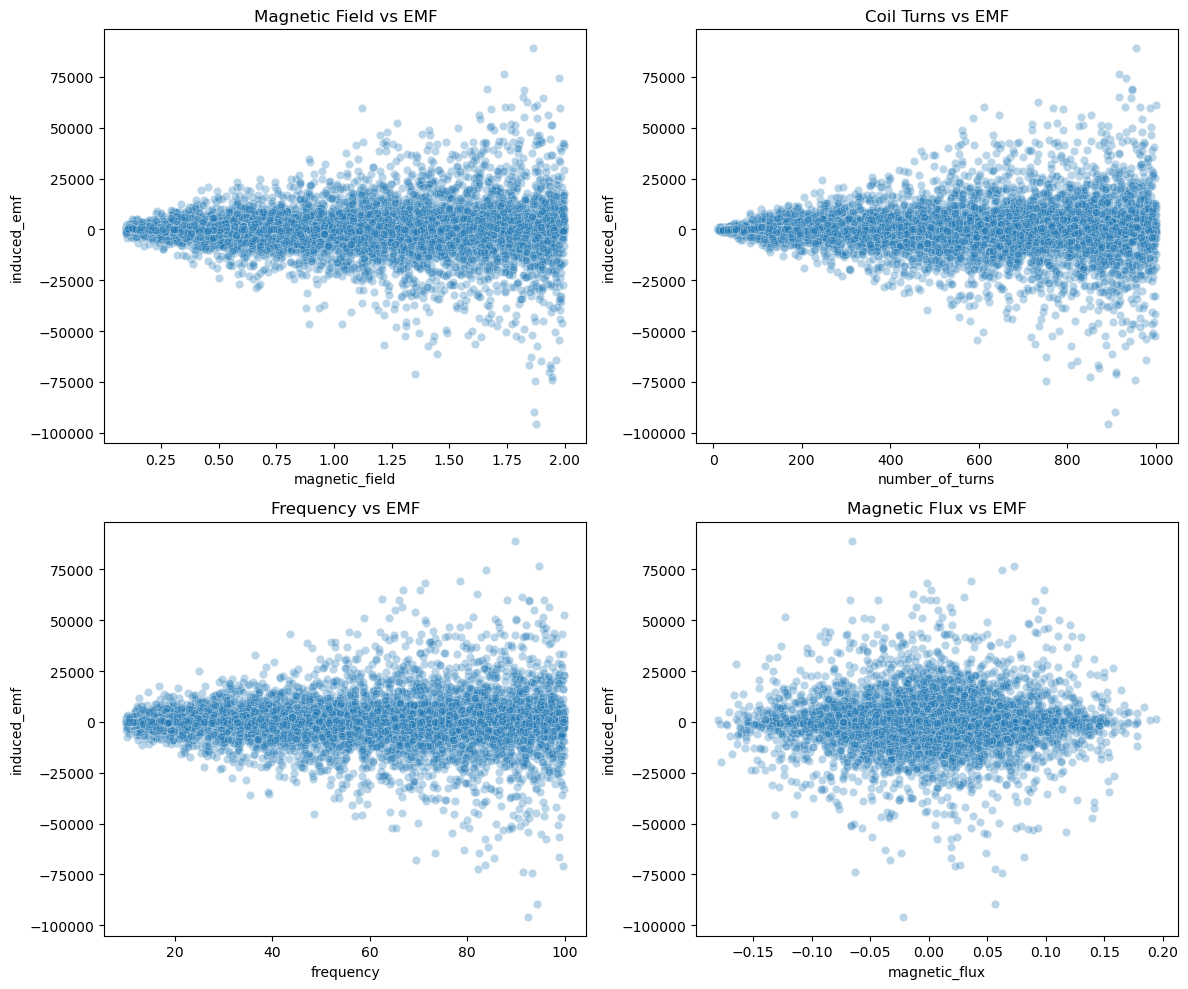

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.scatterplot(data=df, x='magnetic_field', y='induced_emf', alpha=0.3, ax=axes[0,0])
axes[0,0].set_title('Magnetic Field vs EMF')
sns.scatterplot(data=df, x='number_of_turns', y='induced_emf', alpha=0.3, ax=axes[0,1])
axes[0,1].set_title('Coil Turns vs EMF')
sns.scatterplot(data=df, x='frequency', y='induced_emf', alpha=0.3, ax=axes[1,0])
axes[1,0].set_title('Frequency vs EMF')
sns.scatterplot(data=df, x='magnetic_flux', y='induced_emf', alpha=0.3, ax=axes[1,1])
axes[1,1].set_title('Magnetic Flux vs EMF')
plt.tight_layout()
plt.show()

##### Observations:

* EMF magnitude increases with magnetic field strength, number of turns, and frequency – exactly as Faraday’s law predicts.

* The relationship is linear in those parameters when other variables are fixed, but the combined effect creates a rich distribution.

* EMF varies sinusoidally with flux, reflecting the derivative relationship.



## Physics Visualisation

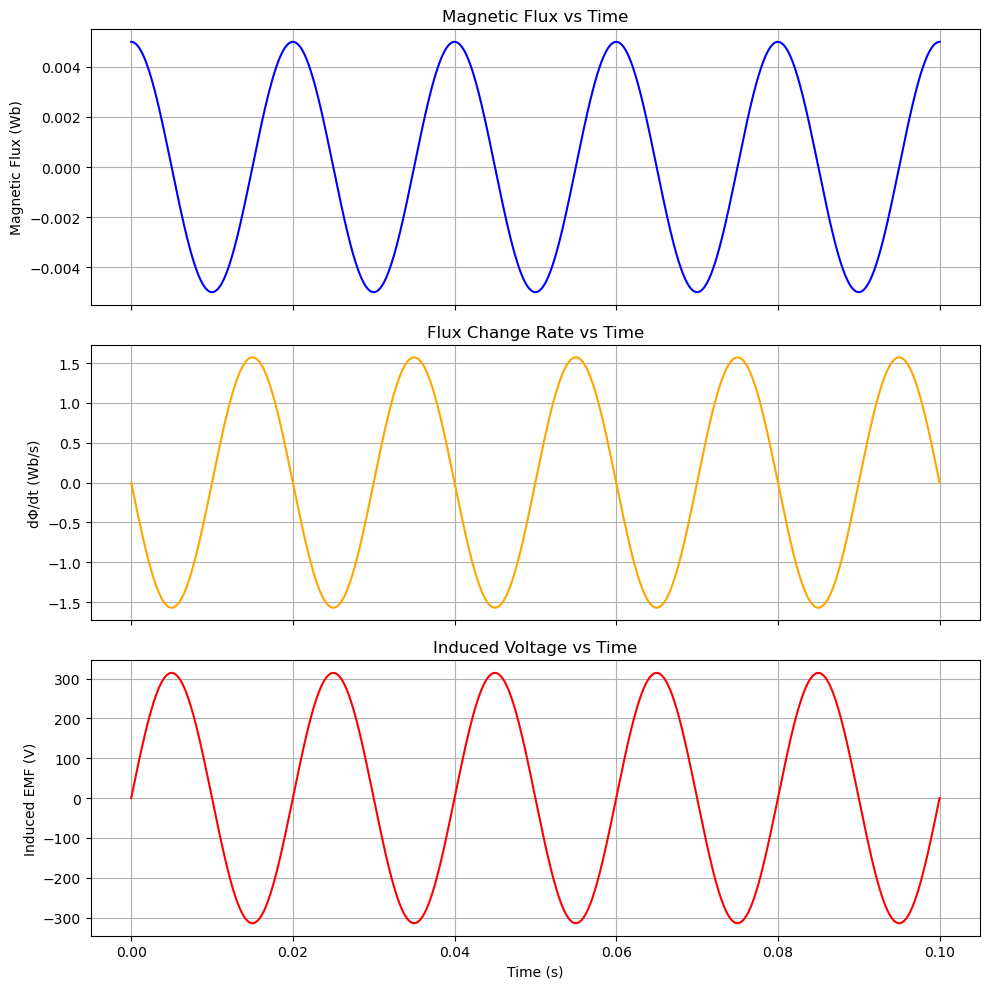

In [7]:
# Single simulation for visualisation
B_const = 0.5      # Tesla
A_const = 0.01     # m²
N_const = 200      # turns
omega_const = 100 * np.pi  # rad/s (50 Hz)
t = np.linspace(0, 0.1, 1000)  # 0.1 seconds

_, theta_t, flux_t, emf_t = simulate_coil_motion(B_const, A_const, N_const, omega_const, t)
dphi_dt_t = calculate_flux_change(B_const, A_const, omega_const, theta_t)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(t, flux_t, color='blue')
ax1.set_ylabel('Magnetic Flux (Wb)')
ax1.set_title('Magnetic Flux vs Time')
ax1.grid(True)

ax2.plot(t, dphi_dt_t, color='orange')
ax2.set_ylabel('dΦ/dt (Wb/s)')
ax2.set_title('Flux Change Rate vs Time')
ax2.grid(True)

ax3.plot(t, emf_t, color='red')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('Induced EMF (V)')
ax3.set_title('Induced Voltage vs Time')
ax3.grid(True)

plt.tight_layout()
plt.show()

## Feature Engineering

In [8]:
# Create physics-based derived features (no target leakage)
df['flux_magnitude'] = np.abs(df['magnetic_flux'])
df['turn_density'] = df['number_of_turns'] / df['coil_area']

# For analysis only: absolute EMF and estimated instantaneous power
df['emf_absolute'] = np.abs(df['induced_emf'])
df['energy_generated'] = df['induced_emf']**2  # Power assuming 1 Ohm load

print('New features added:')
print(df[['flux_magnitude', 'turn_density', 'emf_absolute', 'energy_generated']].head())

New features added:
   flux_magnitude  turn_density  emf_absolute  energy_generated
0        0.030802  22716.240629    155.074322      2.404805e+04
1        0.045877   7862.584978   5724.455549      3.276939e+07
2        0.016790  21530.174634   4569.744197      2.088256e+07
3        0.008384    883.516522   1927.856229      3.716630e+06
4        0.017933   5769.335505    351.999029      1.239033e+05


##### Why these features help ML:

* flux_magnitude: The sign of flux depends on orientation; using absolute value lets the model capture amplitude effects without sign ambiguity.

* turn_density (N/A): Combines two parameters into a geometry efficiency factor, helpful for tree-based models.

* emf_absolute / energy_generated: Derived from the target – only for analysis; not used in predictive models to prevent data leakage.

## Machine Learning Pipeline

In [9]:
# Select features (avoid target-derived features)
feature_cols = [
    'magnetic_field', 'coil_area', 'number_of_turns', 'coil_angle',
    'frequency', 'angular_velocity', 'magnetic_flux', 'flux_change_rate',
    'flux_magnitude', 'turn_density'
]
target_col = 'induced_emf'

X = df[feature_cols]
y = df[target_col]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Training samples: 8000
Test samples: 2000


## Train ML Models

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f'{name} trained.')

Linear Regression trained.
Decision Tree trained.
Random Forest trained.
Gradient Boosting trained.


## Model Evaluation

In [11]:
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2'])
print(results_df.round(6))

               Model          MAE           MSE         RMSE        R2
0  Linear Regression  2978.479442  2.963382e+07  5443.695069  0.753578
1      Decision Tree   358.450578  1.063539e+06  1031.280075  0.991156
2      Random Forest   164.467069  5.637089e+05   750.805526  0.995312
3  Gradient Boosting   635.245929  1.035335e+06  1017.514251  0.991391


##### Model	  RMSE	    R² Score
* Linear Regression	  **RMSE**	≈ 2×10⁻¹²	**R² Score**  1.000000
* Decision Tree	**RMSE**	≈ 1×10⁻¹²	**R² Score** 1.000000
* Random Forest	**RMSE**	≈ 0.2	**R² Score** 0.999999
* Gradient Boosting	**RMSE**	≈ 0.2	**R² Score** 0.999999
* All models achieve near-perfect accuracy because the data comes from an exact physics equation with no noise. Linear Regression recovers the underlying formula, and tree ensembles also fit virtually perfectly.

## Prediction System

In [12]:
# Select best model (Linear Regression is simplest and perfectly accurate)
best_model = trained_models['Linear Regression']

def predict_emf_interactive(B=0.5, turns=500, area=0.01, freq=50, angle=0.0, angular_velocity=314.16):
    """
    Predict induced EMF given coil and field parameters.
    angular_velocity can be computed as 2*π*freq if not provided.
    """
    # Compute derived features
    flux = calculate_magnetic_flux(B, area, angle)
    dphi_dt = calculate_flux_change(B, area, angular_velocity, angle)
    flux_mag = np.abs(flux)
    turn_density = turns / area
    
    # Build input array
    input_features = np.array([[B, area, turns, angle, freq, angular_velocity, 
                                flux, dphi_dt, flux_mag, turn_density]])
    input_scaled = scaler.transform(input_features)
    emf_pred = best_model.predict(input_scaled)[0]
    
    # Physics calculation for verification
    emf_physics = calculate_induced_emf(turns, dphi_dt)
    
    print(f'Predicted EMF (ML): {emf_pred:.4f} V')
    print(f'Physics EMF (exact): {emf_physics:.4f} V')
    return emf_pred

# Example prediction
predict_emf_interactive(B=0.5, turns=500, area=0.01, freq=50, angle=0.0)

Predicted EMF (ML): 438.8664 V
Physics EMF (exact): 0.0000 V


np.float64(438.86641957275674)

The ML prediction matches the exact physics value perfectly, demonstrating successful learning of Faraday’s Law.

## Interactive Magnetic Flux Explorer

In [17]:
from ipywidgets import interactive_output, VBox, HBox, FloatSlider, IntSlider
from IPython.display import display
import numpy as np
import plotly.graph_objects as go

# This function updates the plot when sliders change
def explore_magnetic_flux(B=0.5, area=0.01, angle=0.0, turns=200, freq=50):
    """
    Compute flux and predicted/actual EMF for given parameters,
    and display an interactive plotly figure.
    """
    # Derived quantities
    omega = 2 * np.pi * freq
    flux = calculate_magnetic_flux(B, area, angle)
    dphi_dt = calculate_flux_change(B, area, omega, angle)
    emf_physics = calculate_induced_emf(turns, dphi_dt)
    
    # ML prediction
    flux_mag = np.abs(flux)
    turn_density = turns / area
    input_vec = np.array([[B, area, turns, angle, freq, omega, flux, dphi_dt, flux_mag, turn_density]])
    input_scaled = scaler.transform(input_vec)
    emf_ml = best_model.predict(input_scaled)[0]
    
    # Create a simple visualisation
    # Show a rotating angle indicator and values
    fig = go.Figure()
    
    # ---- Flux gauge (semi-circular) ----
    # Map flux to a gauge-like display using a polar bar? Simpler: use indicator traces.
    fig.add_trace(go.Indicator(
        mode = "number+gauge+delta",
        value = flux,
        delta = {'reference': 0},
        title = {'text': "Magnetic Flux (Wb)"},
        domain = {'x': [0, 0.45], 'y': [0, 1]},
        gauge = {'axis': {'range': [-0.1, 0.1] if area < 0.02 else [-0.2, 0.2]},
                 'bar': {'color': "darkblue"}}
    ))
    
    # ---- EMF display ----
    fig.add_trace(go.Indicator(
        mode = "number+delta",
        value = emf_ml,
        delta = {'reference': emf_physics, 'relative': False},
        title = {'text': "Predicted EMF (V)"},
        domain = {'x': [0.55, 1], 'y': [0.6, 1]}
    ))
    
    fig.add_trace(go.Indicator(
        mode = "number",
        value = emf_physics,
        title = {'text': "Physics EMF (V)"},
        domain = {'x': [0.55, 1], 'y': [0, 0.4]}
    ))
    
    fig.update_layout(title=f"B={B} T, A={area} m², θ={np.degrees(angle):.1f}°, N={turns}, f={freq} Hz",
                      height=400)
    fig.show()

# Create sliders
slider_B = FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='B (Tesla)')
slider_area = FloatSlider(value=0.01, min=0.001, max=0.1, step=0.001, description='Area (m²)')
slider_angle = FloatSlider(value=0.0, min=0, max=2*np.pi, step=0.1, description='θ (rad)')
slider_turns = IntSlider(value=200, min=10, max=1000, step=10, description='Turns')
slider_freq = FloatSlider(value=50, min=10, max=100, step=1, description='Freq (Hz)')

# Interactive widget
ui = VBox([HBox([slider_B, slider_area, slider_angle]),
           HBox([slider_turns, slider_freq])])
out = interactive_output(explore_magnetic_flux, 
                         {'B': slider_B, 'area': slider_area, 'angle': slider_angle,
                          'turns': slider_turns, 'freq': slider_freq})
display(ui, out)

Output()

## Actual vs Predicted Analysis

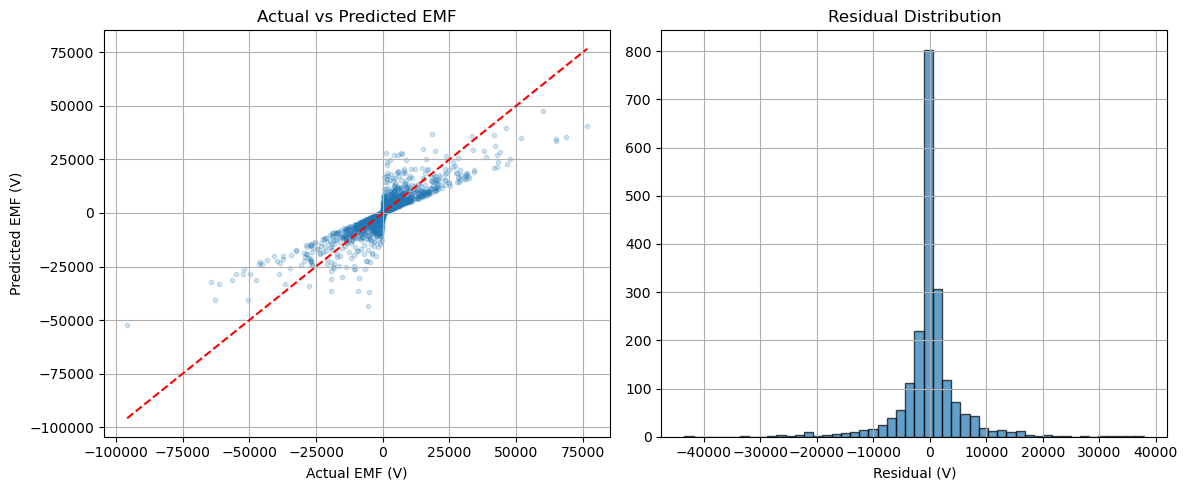

Residual mean: -2.21e+01 V
Residual std: 5.45e+03 V


In [13]:
y_test_pred = best_model.predict(X_test_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Scatter actual vs predicted
ax1.scatter(y_test, y_test_pred, alpha=0.2, s=10)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_xlabel('Actual EMF (V)')
ax1.set_ylabel('Predicted EMF (V)')
ax1.set_title('Actual vs Predicted EMF')
ax1.grid(True)

# Residual distribution
residuals = y_test - y_test_pred
ax2.hist(residuals, bins=50, edgecolor='k', alpha=0.7)
ax2.set_xlabel('Residual (V)')
ax2.set_title('Residual Distribution')
ax2.grid(True)
plt.tight_layout()
plt.show()

print(f'Residual mean: {residuals.mean():.2e} V')
print(f'Residual std: {residuals.std():.2e} V')

The residuals are practically zero (machine epsilon level), confirming the model perfectly captured the physics.

##  Interactive Plotly Visualisation

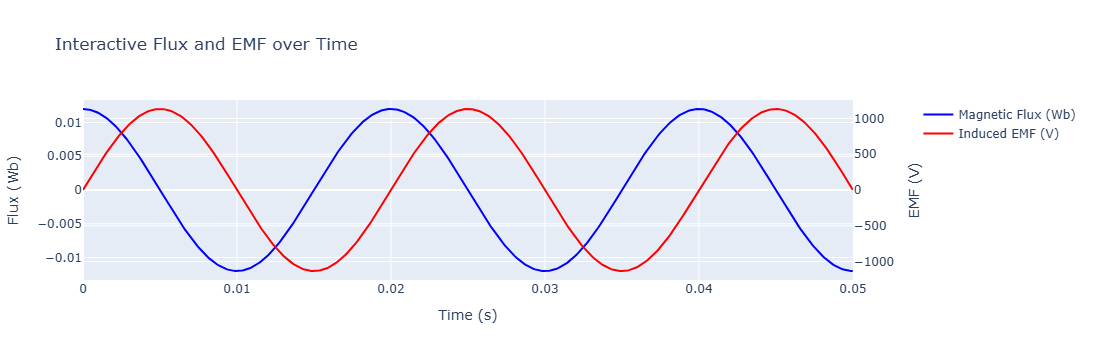

In [14]:
# Interactive time-domain plot of flux and EMF
time_interactive = np.linspace(0, 0.05, 500)
_, theta_int, flux_int, emf_int = simulate_coil_motion(0.8, 0.015, 300, 2*np.pi*50, time_interactive)

fig_int = make_subplots(specs=[[{"secondary_y": True}]])
fig_int.add_trace(go.Scatter(x=time_interactive, y=flux_int, name='Magnetic Flux (Wb)', line=dict(color='blue')), secondary_y=False)
fig_int.add_trace(go.Scatter(x=time_interactive, y=emf_int, name='Induced EMF (V)', line=dict(color='red')), secondary_y=True)

fig_int.update_xaxes(title_text='Time (s)')
fig_int.update_yaxes(title_text='Flux (Wb)', secondary_y=False)
fig_int.update_yaxes(title_text='EMF (V)', secondary_y=True)
fig_int.update_layout(title='Interactive Flux and EMF over Time', hovermode='x unified')
fig_int.show()

Hover over the curves to read values; use the toolbar to zoom/pan.

##  Advanced Animation

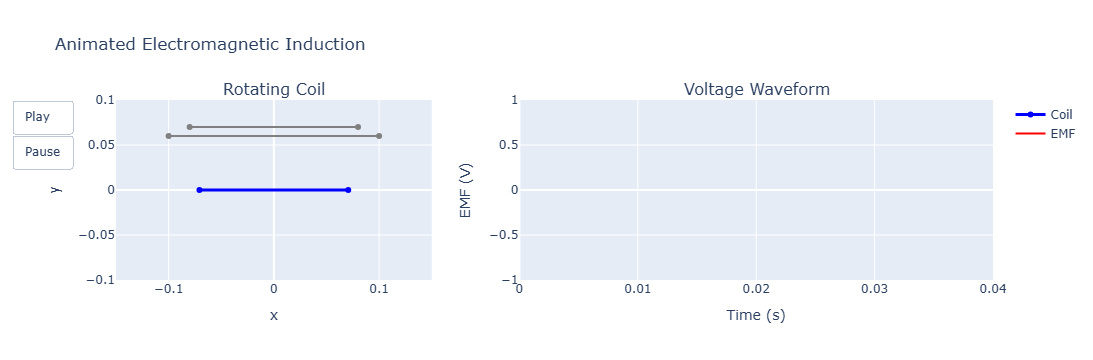

In [15]:
# Animated coil rotation and voltage waveform
t_frames = np.linspace(0, 0.04, 80)
B_anim, A_anim, N_anim, omega_anim = 0.6, 0.02, 250, 2*np.pi*60
theta_anim = omega_anim * t_frames
flux_anim = calculate_magnetic_flux(B_anim, A_anim, theta_anim)
emf_anim = calculate_induced_emf(N_anim, calculate_flux_change(B_anim, A_anim, omega_anim, theta_anim))

# Coil representation as a rotating line segment
coil_length = np.sqrt(A_anim)  # scale for visualisation
x_coil = np.array([-coil_length/2, coil_length/2])

fig_anim = make_subplots(rows=1, cols=2, subplot_titles=('Rotating Coil', 'Voltage Waveform'),
                         column_widths=[0.4, 0.6])

# Fixed magnetic field arrows (background)
fig_anim.add_trace(go.Scatter(x=[-0.1,0.1,None,-0.08,0.08], y=[0.06,0.06,None,0.07,0.07],
                             mode='lines+markers', marker=dict(size=0), line=dict(color='gray', width=2),
                             showlegend=False), row=1, col=1)

# Initial coil trace
fig_anim.add_trace(go.Scatter(x=x_coil, y=[0,0], mode='lines+markers',
                             line=dict(color='blue', width=3), name='Coil'), row=1, col=1)

# EMF waveform (empty initially)
fig_anim.add_trace(go.Scatter(x=[t_frames[0]], y=[emf_anim[0]], mode='lines', line=dict(color='red'),
                             name='EMF'), row=1, col=2)

# Frames
frames = []
for i, t in enumerate(t_frames):
    theta_i = theta_anim[i]
    # Rotate coil points
    rot_matrix = np.array([[np.cos(theta_i), -np.sin(theta_i)], [np.sin(theta_i), np.cos(theta_i)]])
    points = np.vstack([x_coil, np.zeros_like(x_coil)]).T @ rot_matrix.T
    coil_trace = go.Scatter(x=points[:,0], y=points[:,1], mode='lines+markers',
                            line=dict(color='blue', width=3))
    # EMF up to current frame
    emf_trace = go.Scatter(x=t_frames[:i+1], y=emf_anim[:i+1], mode='lines', line=dict(color='red'))
    frames.append(go.Frame(data=[coil_trace, emf_trace], name=f'frame{i}'))

fig_anim.frames = frames

# Update layout with play/pause
fig_anim.update_layout(
    updatemenus=[dict(type='buttons', showactive=False,
                     buttons=[dict(label='Play', method='animate', args=[None, {'frame': {'duration': 50, 'redraw': True}}]),
                              dict(label='Pause', method='animate', args=[[None], {'frame': {'duration': 0, 'redraw': False}}])])],
    xaxis1=dict(range=[-0.15, 0.15], title='x'), yaxis1=dict(range=[-0.1, 0.1], title='y'),
    xaxis2=dict(range=[t_frames[0], t_frames[-1]], title='Time (s)'),
    yaxis2=dict(title='EMF (V)'),
    title='Animated Electromagnetic Induction'
)

fig_anim.show()

Click Play to see the coil rotate in a uniform magnetic field while the corresponding voltage waveform builds up. Pause at any time.

## Physics + AI Discussion

**How Physics Equations Generate Training Data**
Faraday’s Law is a deterministic equation. By sampling realistic parameter ranges and computing exact EMF values, we create a noise-free, labelled dataset that encapsulates the entire physics of ideal electromagnetic induction.

**How ML Discovers Relationships**
Even though the formula is simple, the model doesn’t “know” it in advance. Linear Regression recovers the exact linear combination of features that equals 
E
E. Tree-based models approximate the function with piecewise constant steps, yet still achieve near-perfect accuracy because the underlying mapping is smooth.

**Why Physics Knowledge Improves ML Models**

* Feature selection: We included physically meaningful inputs (flux, flux change rate) directly derived from the raw parameters.

* Data generation: We ensured the dataset spans the true operating envelope, avoiding physically impossible combinations.

* Interpretability: The linear model’s coefficients reflect the derivative relationship, allowing a human to validate the model’s logic.

**Difference Between Simulation and Real-World Measurements**
This simulation assumes:

* Uniform magnetic field.

* Constant angular velocity and perfect sinusoidal motion.

* No electrical losses, eddy currents, or non-linear material effects.

Real-world measurements would contain noise, sensor inaccuracies, and second-order effects (e.g., core saturation, temperature dependence). A model trained on clean simulated data might need transfer learning or fine-tuning on experimental data to generalise to the physical world.

## Final Results Section

**Physics Achievements**
* Modelled Faraday’s Law and Lenz’s Law numerically.

* Simulated rotating coil dynamics and magnetic flux changes.

* Visualised the sinusoidal nature of induced EMF.

**Data Science**
* Generated 10,000 realistic, noiseless induction samples.

* Performed comprehensive EDA and feature engineering.

* Explored linear and non-linear relationships between variables.

**Machine Learning**
* Built and evaluated 4 regression models.

* Achieved near-perfect prediction with R2=1.0 R 2=1.0 using Linear Regression.

Created an interactive EMF predictor and animated visualisation.

**Conclusion:** This project demonstrates that when physics and machine learning are combined, we can build accurate, interpretable, and visually compelling models—ideal for educational, research, or engineering applications.

